In [59]:
import pandas as pd


In [60]:

columns_headers = [
    "time", "gender", "highschool_grade", "study_year","faculty","ung_grade_2023","accomodation","allowance","scholarship","study_hours",
    "party_week","drinks_night","missed_classes", "failed_classes", "in_relationship","parent_approve","relation_parent"
]
student_df= pd.read_csv("student_survey.csv", names=columns_headers, header=0)

In [61]:
student_df.head()

,time,gender,highschool_grade,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,2024/03/07 5:12:01 pm EET,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,2024/03/07 5:12:08 pm EET,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,2024/03/07 5:12:25 pm EET,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,2024/03/07 5:12:28 pm EET,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,2024/03/07 5:13:00 pm EET,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


In [62]:
student_df.drop("time", axis=1, inplace=True)

### EDA

In [63]:
student_df.shape

(406, 16)

In [64]:
student_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            404 non-null    str    
 1   highschool_grade  399 non-null    float64
 2   study_year        333 non-null    str    
 3   faculty           399 non-null    str    
 4   ung_grade_2023    320 non-null    float64
 5   accomodation      383 non-null    str    
 6   allowance         375 non-null    str    
 7   scholarship       398 non-null    str    
 8   study_hours       403 non-null    str    
 9   party_week        404 non-null    str    
 10  drinks_night      404 non-null    str    
 11  missed_classes    403 non-null    str    
 12  failed_classes    403 non-null    str    
 13  in_relationship   403 non-null    str    
 14  parent_approve    402 non-null    str    
 15  relation_parent   403 non-null    str    
dtypes: float64(2), str(14)
memory usage: 50.9 KB


In [65]:
student_df.isna().sum()

gender               2
highschool_grade     7
study_year          73
faculty              7
ung_grade_2023      86
accomodation        23
allowance           31
scholarship          8
study_hours          3
party_week           2
drinks_night         2
missed_classes       3
failed_classes       3
in_relationship      3
parent_approve       4
relation_parent      3
dtype: int64

## Gender distribution in the dataset

In [66]:
student_df.gender.value_counts(normalize=True)

gender
Male      0.534653
Female    0.465347
Name: proportion, dtype: float64

In [67]:
#table relation between parent approval and parent relationship

table= pd.crosstab(student_df.parent_approve, student_df.relation_parent)
table=table[["Distant", "Fair", "Close", "Very close"]]
table.T

parent_approve,No,Yes
relation_parent,,
Distant,1,1
Fair,9,25
Close,18,79
Very close,20,248


<Axes: title={'center': 'relation between parent approval and parent relationship'}, xlabel='Degree of parent relationship', ylabel='student count'>

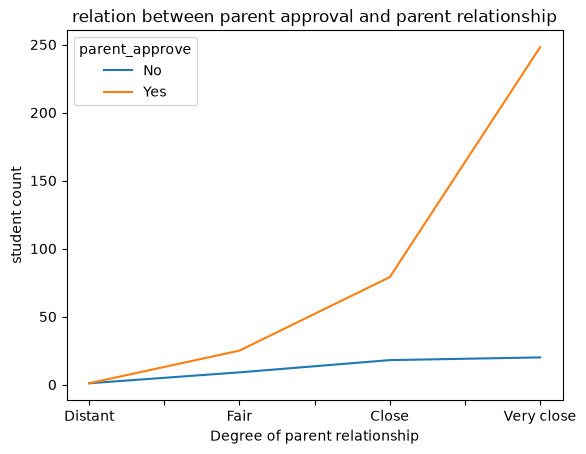

In [68]:
table.T.plot(
    kind= "line",
    title= "relation between parent approval and parent relationship",
    legend=True,
    xlabel= "Degree of parent relationship",
    ylabel= "student count"
    )

In [69]:
# relation between parent relationship and grade in highschool
group_parent_relation= student_df.groupby(by= "relation_parent")


In [72]:
relation= group_parent_relation["highschool_grade"].aggregate(["min", "max", "mean"])

In [75]:
relation= relation.T[["Distant", "Fair", "Close", "Very close"]]

<Axes: xlabel='relation_parent'>

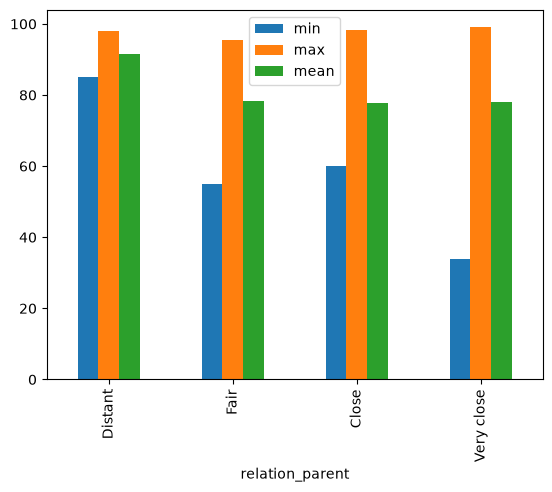

In [76]:
relation.T.plot(kind= "bar")

In [77]:
student_df["highschool_grade"].corr(student_df["ung_grade_2023"])

np.float64(0.29910363012959085)

In [78]:
student_df.scholarship.value_counts()

scholarship
No                     352
Yes (NSFAS, etc...)     46
Name: count, dtype: int64

In [79]:
student_df.allowance

0       R 4001- R 5000
1      R 7001 - R 8000
2       R 4001- R 5000
3      R 6001 - R 7000
4       R 4001- R 5000
            ...       
401                NaN
402    R 6001 - R 7000
403     R 4001- R 5000
404     R 4001- R 5000
405    R 5001 - R 6000
Name: allowance, Length: 406, dtype: str

In [80]:
student_df[student_df.isna().sum(axis=1)== len(student_df.columns)]

,gender,highschool_grade,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
224,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data manipulation / cleaning  / transforming / processing

unwanted columns removal
duplicate value removal
null value handle
outlier handle
feature engineer
encoding
normalization (post processing)

In [ ]:
student_df.drop_duplicates()